# Phase 3.A — InsightFace Smoke Test

Goal: understand what InsightFace returns *before* writing the production filter.

Five questions:
1. Does the model load with CUDA provider?
2. Inference timing (cold vs warm)?
3. What attributes live on each detected `Face` object?
4. How are the 5 landmarks (`kps`) ordered?
5. Are coordinates pixel-space or normalized?

Important: InsightFace expects BGR, not RGB. We convert before inference.

### Notebook config and imports 

In [1]:
from __future__ import annotations 

import time 
from pathlib import Path 

import cv2 
import numpy as np 

from src.constants import IMAGES_DIR
from src.logger.custom_logger import configure_logger,logger 
from src.utils.io import ImageLoader 
from insightface.app import FaceAnalysis


12:47:11 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\12-47-11.log


In [2]:
configure_logger(log_level="INFO")

12:47:17 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\12-47-17.log


WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-10/12-47-17.log')

In [3]:
loader = ImageLoader()

In [4]:
t0 = time.perf_counter()

app = FaceAnalysis(name="buffalo_l",
                   allowed_modules=['detection'], # allowed_modules tells InsightFace which parts of model pipeline to load
                   providers=["CUDAExecutionProvider", "CPUExecutionProvider"])

app.prepare(ctx_id=0,det_size=(640,640)) # ctx_id tells InsightFace to run on GPU/CPU
# prepare loads the weights and sets input size 
load_ms = (time.perf_counter() - t0) * 1000 
print(f"Loaded InsightFace model in {load_ms:.0f}ms") 

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\rsurs/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecu

### Inspect output structure of InsightFace

In [5]:
sample_path  = IMAGES_DIR / "crop (33).png"
crop = loader.load(sample_path)
print(f"Loaded image {crop.crop_id}, shape: {crop.image.shape}")

img_bgr = cv2.cvtColor(crop.image,cv2.COLOR_RGB2BGR)

# cold inference
t0 = time.perf_counter()
faces = app.get(img_bgr)
cold_ms = (time.perf_counter() - t0) * 1000 

# warm inference
t0 = time.perf_counter()
faces = app.get(img_bgr)
warm_ms = (time.perf_counter() - t0) * 1000 


print(f"cold inference time: {cold_ms:.0f}")
print(f"warm inference time: {warm_ms:.0f}")
print(f"No of faces detected: {len(faces)}")
print("type of result: ",type(faces))

if faces:
    print(f"type of one face: ",type(faces[0]))

12:47:18 | INFO     | src.utils.io:load:61 | Loaded crop (33).png | shape: ((163, 600, 3)) | bytes: 293400
Loaded image crop (33), shape: (600, 163, 3)
cold inference time: 283
warm inference time: 13
No of faces detected: 1
type of result:  <class 'list'>
type of one face:  <class 'insightface.app.common.Face'>


In [6]:
faces

[{'bbox': array([114.49842 ,  16.544392, 154.10854 ,  79.99805 ], dtype=float32),
  'kps': array([[139.08041 ,  41.397396],
         [147.08063 ,  40.60189 ],
         [152.96062 ,  52.61599 ],
         [141.75006 ,  65.039116],
         [147.58784 ,  64.826744]], dtype=float32),
  'det_score': np.float32(0.7912696)}]

### Inspecting the InsightFace output attributes

In [7]:
face = faces[0]
print("Examining attributes on Face object")
for attr in dir(face):
    if attr.startswith("_"):
        continue
    
    try:
        value = getattr(face,attr) 
        
        if callable(value): 
            # can the object be called as a function 
            continue

        shape = getattr(value,"shape",None)
        print(f"  {attr:<15}  type={type(value).__name__}  "
                  f"shape={shape if shape is not None else 'N/A'}")
    except Exception as exc:
        print(f"  {attr}: <error: {exc}>")

Examining attributes on Face object
  bbox             type=ndarray  shape=(4,)
  det_score        type=float32  shape=()
  embedding_norm   type=NoneType  shape=N/A
  kps              type=ndarray  shape=(5, 2)
  normed_embedding  type=NoneType  shape=N/A
  sex              type=NoneType  shape=N/A


1. `bbox`: Indicates where face is in the image ?. Contains 4 coordinates `[x1,y1,x2,y2]`.

2. `det_score`: This tells how confident detector identifies the face ?. ex, 0.98

3. `kps`: This means keypoints which denote important facial landmark coordinates. Consists of 5 points:
    - left eye 
    - right eye 
    - nose 
    - left mouth corner 
    - right mouth corner 

4. `embedding`: Most important recognition feature. A numeric representation vector of face. Usually `shape=(512,)`. 
    - If we have faces of same person embeddings are closer. 
    - If we have different faces embeddings are far apart.

5. `normed_embedding`: Embedding after normalization. Vector length adds upto 1.

6. `sex`: Predicted sex from face. 0 maps to female and 1 maps to male.

### Examing the output

In [8]:
face = faces[0]
print(f"bbox (pixels): {face.bbox}")
print(f"x1={face.bbox[0]:.1f}, y1={face.bbox[1]:.1f}")
print(f"x2={face.bbox[2]:.1f}, y2={face.bbox[3]:.1f}\n")
print(f"width={face.bbox[2] - face.bbox[0]:.1f}, height={face.bbox[3] - face.bbox[1]:.1f}\n")
print(f"Detection confidence:{face.det_score:.3f}")


print(f"\nKeypoints (kps), shape {face.kps.shape}:")
print(f"  [right_eye]    {face.kps[0]}")
print(f"  [left_eye]     {face.kps[1]}")
print(f"  [nose]         {face.kps[2]}")
print(f"  [right_mouth]  {face.kps[3]}")
print(f"  [left_mouth]   {face.kps[4]}")

print(f"\nCrop dimensions for sanity-check: H={crop.height}, W={crop.width}")


bbox (pixels): [114.49842   16.544392 154.10854   79.99805 ]
x1=114.5, y1=16.5
x2=154.1, y2=80.0

width=39.6, height=63.5

Detection confidence:0.791

Keypoints (kps), shape (5, 2):
  [right_eye]    [139.08041   41.397396]
  [left_eye]     [147.08063  40.60189]
  [nose]         [152.96062  52.61599]
  [right_mouth]  [141.75006   65.039116]
  [left_mouth]   [147.58784   64.826744]

Crop dimensions for sanity-check: H=600, W=163


### Visualizing the landmarks and bbox 

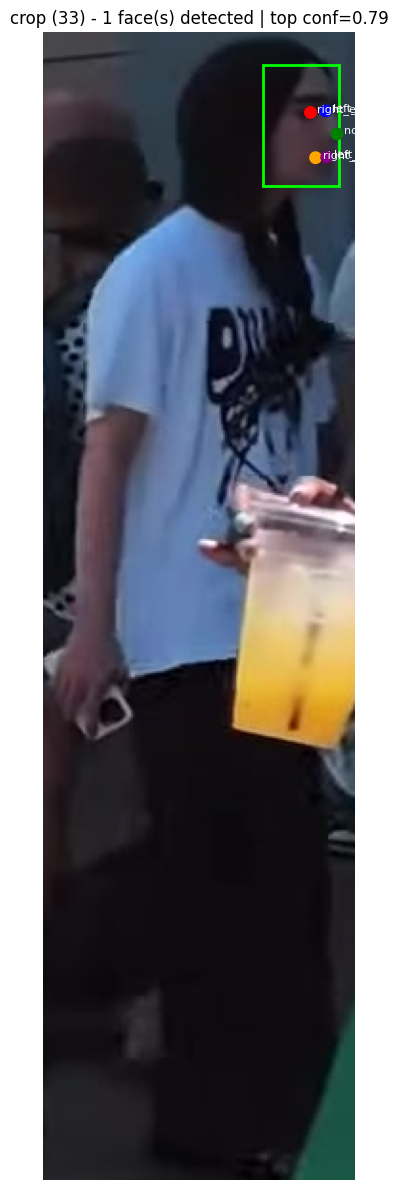

In [10]:
import matplotlib.pyplot as plt 
from matplotlib.patches import Circle,Rectangle
from src.constants import LANDMARK_NAMES,COLORS

fig,ax = plt.subplots(figsize=(8,12))
ax.imshow(crop.image)

for face in faces:
    x1,y1,x2,y2 = face.bbox 
    ax.add_patch(Rectangle((x1,y1),
                           x2 - x1,
                           y2 - y1,
                           fill=False,
                           edgecolor="lime",
                           linewidth=2))
    
    for i,((x,y),name,color) in enumerate(zip(face.kps,LANDMARK_NAMES,COLORS)):
        ax.add_patch(Circle((x,y),radius=3,color=color))
        ax.annotate(name,(x,y),fontsize=8,color="white",xytext=(5,0),textcoords="offset points")

ax.set_title(f"{crop.crop_id} - {len(faces)} face(s) detected | "
             f"top conf={faces[0].det_score:.2f}"
)
ax.axis("off")
plt.tight_layout()
plt.show()
